# PHỤ LỤC: Thử nghiệm độ nhạy cảm của `min_impurity_decrease`

Notebook này được tạo ra để kiểm chứng giả thuyết: **Ép cây dừng mọc sớm bằng `min_impurity_decrease` có thực sự làm giảm Overfitting cho dữ liệu Text hay không, và thời gian chạy thay đổi ra sao.**

Để tối ưu tốc độ cho bạn trải nghiệm nhanh, chúng ta sẽ:
- Cố định số lượng cây ở mức thấp (`n_estimators=50`)
- Tập trung GridSearch duy nhất vào tham số `min_impurity_decrease`
- Chỉ chạy Cross-Validation 3 folds (`cv=3`)

In [5]:
import joblib
import time
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data' / 'welfake'

print("Đang tải dữ liệu WELFake...")
X_train = joblib.load(DATA_DIR / 'X_train_tfidf.pkl')
y_train = joblib.load(DATA_DIR / 'y_train.pkl')
print("Tải xong! Kích thước X_train:", X_train.shape)

Đang tải dữ liệu WELFake...
Tải xong! Kích thước X_train: (50451, 5000)


In [2]:
print("Thiết lập Random Forest (n_estimators=50 cho nhanh)...")
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Tập trung search trên min_impurity_decrease
param_grid = {
    'min_impurity_decrease': [0.0, 0.0001, 0.001, 0.01]
}

# Dùng cv=3 để tiết kiệm thời gian
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=3
)

print("Bắt đầu chạy GridSearch...")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

print("\n" + "="*50)
print(f"Tổng thời gian GridSearch: {end_time - start_time:.2f} giây")
print("="*50)

results = pd.DataFrame(grid_search.cv_results_)
for i, row in results.iterrows():
    val = row['param_min_impurity_decrease']
    score = row['mean_test_score']
    fit_time = row['mean_fit_time']
    print(f"min_impurity_decrease: {val:<6} | F1-Score CV: {score:.4f} | Thời gian train 1 fold: {fit_time:.2f} giây")

Thiết lập Random Forest (n_estimators=50 cho nhanh)...
Bắt đầu chạy GridSearch...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV 1/3] END .........min_impurity_decrease=0.0;, score=0.939 total time=  14.1s
[CV 2/3] END .........min_impurity_decrease=0.0;, score=0.934 total time=  16.1s
[CV 3/3] END .........min_impurity_decrease=0.0;, score=0.939 total time=  15.7s
[CV 1/3] END ......min_impurity_decrease=0.0001;, score=0.930 total time=   7.6s
[CV 2/3] END ......min_impurity_decrease=0.0001;, score=0.927 total time=   7.7s
[CV 3/3] END ......min_impurity_decrease=0.0001;, score=0.932 total time=   8.8s
[CV 1/3] END .......min_impurity_decrease=0.001;, score=0.875 total time=   1.5s
[CV 2/3] END .......min_impurity_decrease=0.001;, score=0.870 total time=   1.7s
[CV 3/3] END .......min_impurity_decrease=0.001;, score=0.879 total time=   1.6s
[CV 1/3] END ........min_impurity_decrease=0.01;, score=0.788 total time=   0.7s
[CV 2/3] END ........min_impurity_decrease=0.01;

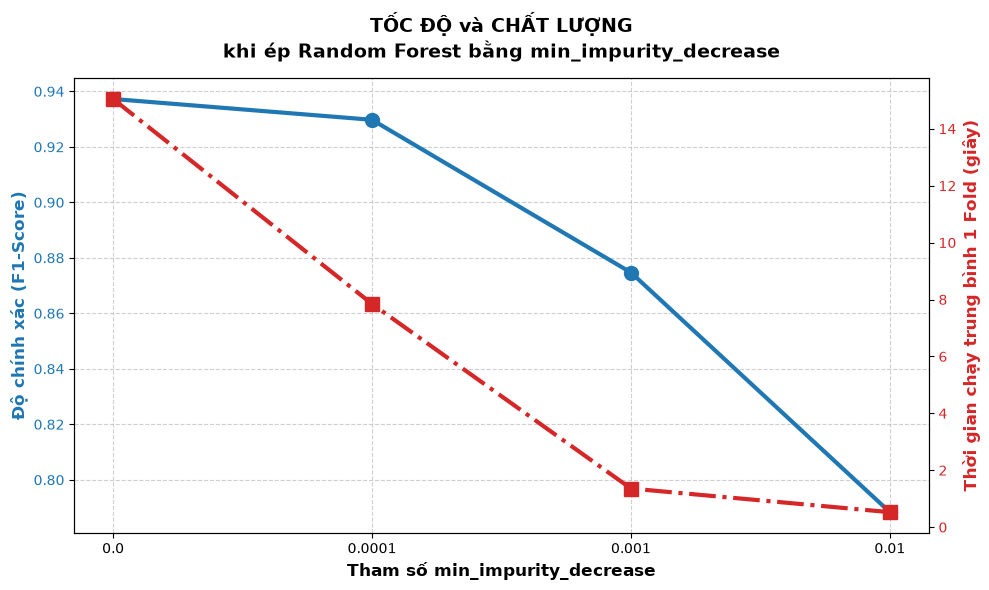

In [4]:
# Vẽ biểu đồ trực quan hóa
impurity_vals = [str(x) for x in param_grid['min_impurity_decrease']]
f1_scores = results['mean_test_score'].values
fit_times = results['mean_fit_time'].values

fig, ax1 = plt.subplots(figsize=(10, 6))

# Vẽ đường Độ chính xác (F1-Score) - Trục Y bên trái
color1 = 'tab:blue'
ax1.set_xlabel('Tham số min_impurity_decrease', fontsize=12, fontweight='bold')
ax1.set_ylabel('Độ chính xác (F1-Score)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(impurity_vals, f1_scores, marker='o', color=color1, linewidth=3, markersize=10, label='F1-Score')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

# Tạo Trục Y thứ 2 bên phải để vẽ Thời gian Train
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Thời gian chạy trung bình 1 Fold (giây)', color=color2, fontsize=12, fontweight='bold')  
ax2.plot(impurity_vals, fit_times, marker='s', color=color2, linewidth=3, markersize=10, linestyle='-.', label='Thời gian Train')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('TỐC ĐỘ và CHẤT LƯỢNG\nkhi ép Random Forest bằng min_impurity_decrease', fontsize=14, pad=15, fontweight='bold')
fig.tight_layout()  
plt.show()